In [1]:
import json
import pandas as pd
import re
import os
from pathlib import Path
import time
import hashlib
from itertools import islice
import requests
import networkx as nx
from dotenv import load_dotenv
import  random
from itertools import islice
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import networkx as nx
from sklearn.cluster import KMeans, DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from itertools import combinations








# STEP 5 : Dataset Partition Mục đích: Chia dữ liệu để huấn luyện và đánh giá

Vì các mô hình phân cụm là mô hình học ko giám sát nên ko cần phân cụm

---------------------------------------------------------------

# Step 6. Data Modelling

Mục đích: Thử nghiệm các thuật toán phân cụm khác nhau (Kmean,dbscan)


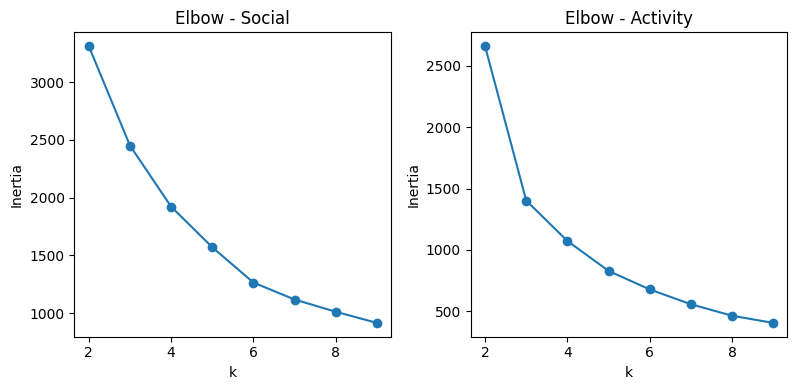

In [18]:
plt.figure(figsize=(16,4))

for i, (name, cols) in enumerate([
    ('Social', ['friend_count','social_factor','group_count','big_group_member']),
    ('Activity', ['total_games','total_playtime_hours','avg_playtime_per_game']),
]):
    X_scaled = StandardScaler().fit_transform(df[cols].fillna(0))
    inertias = []
    for k in range(2, 10):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_scaled)
        inertias.append(km.inertia_)
    
    plt.subplot(1,4,i+1)
    plt.plot(range(2,10), inertias, marker='o')
    plt.title(f'Elbow - {name}')
    plt.xlabel('k')
    plt.ylabel('Inertia')

plt.tight_layout()
plt.show()


In [19]:
#  PHÂN CỤM XÃ HỘI 
def cluster_social(df, n_clusters=3):
    df_s = df.copy()
    cols = ['friend_count', 'social_factor', 'group_count', 'big_group_member']
    X_scaled = StandardScaler().fit_transform(df_s[cols].fillna(0))

    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    db = DBSCAN(eps=0.5, min_samples=8)

    df_s['kmeans'] = km.fit_predict(X_scaled)
    df_s['dbscan'] = db.fit_predict(X_scaled)
    return df_s


# PHÂN CỤM HOẠT ĐỘNG 
def cluster_activity(df, n_clusters=3):
    df_a = df.copy()
    cols = ['total_games', 'total_playtime_hours', 'avg_playtime_per_game']
    X_scaled = StandardScaler().fit_transform(df_a[cols].fillna(0))

    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    db = DBSCAN(eps=0.6, min_samples=10)

    df_a['kmeans'] = km.fit_predict(X_scaled)
    df_a['dbscan'] = db.fit_predict(X_scaled)
    return df_a


social_cluster      = cluster_social(df)
activity_cluster    = cluster_activity(df)




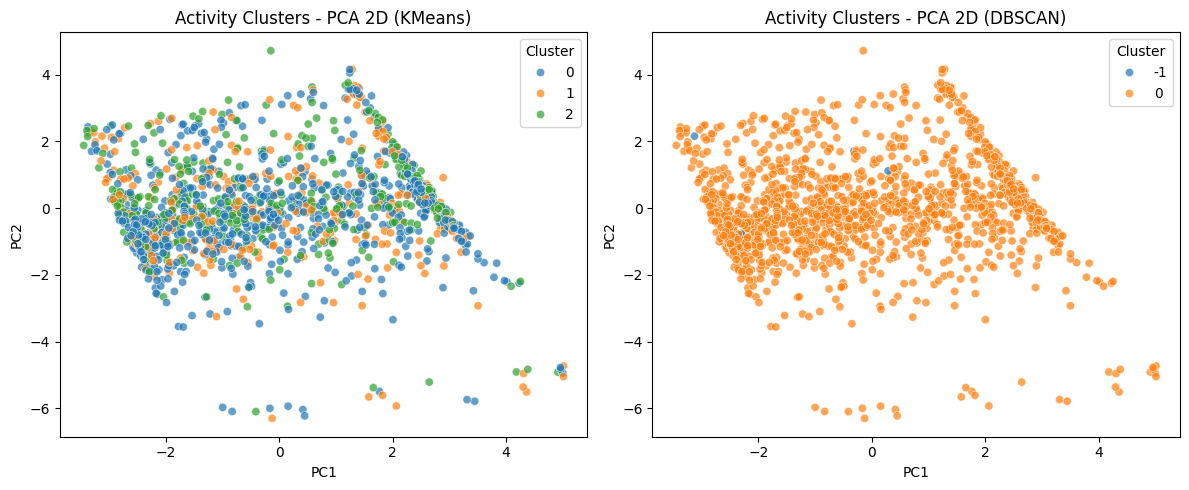

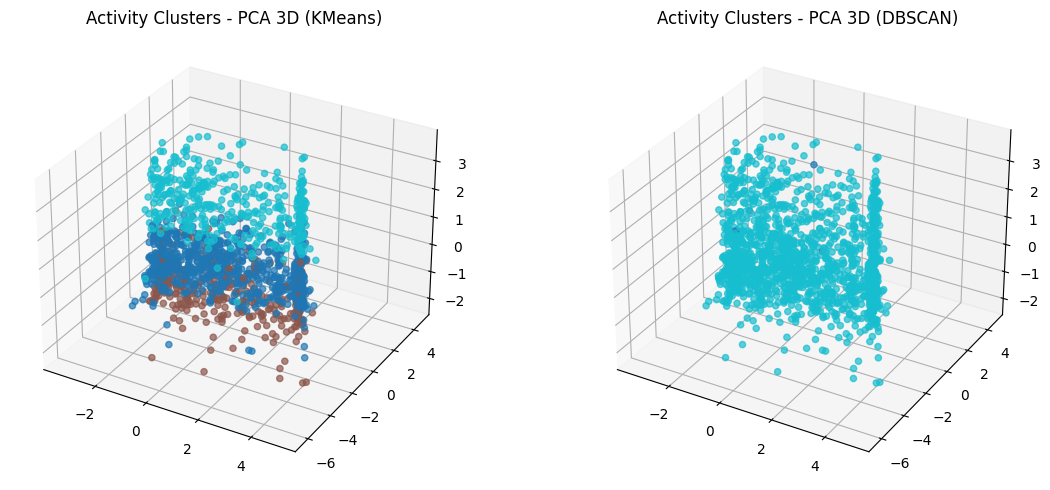

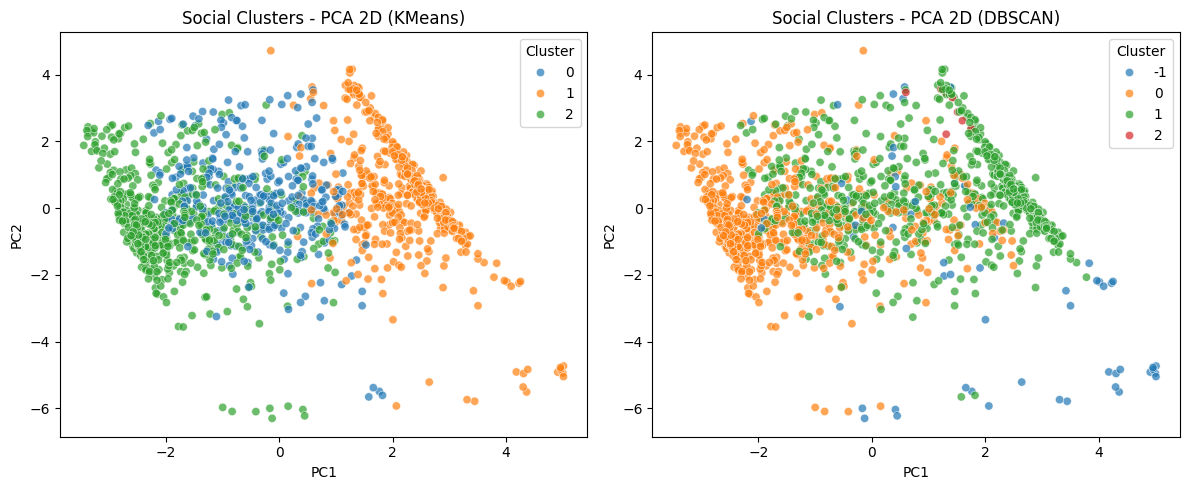

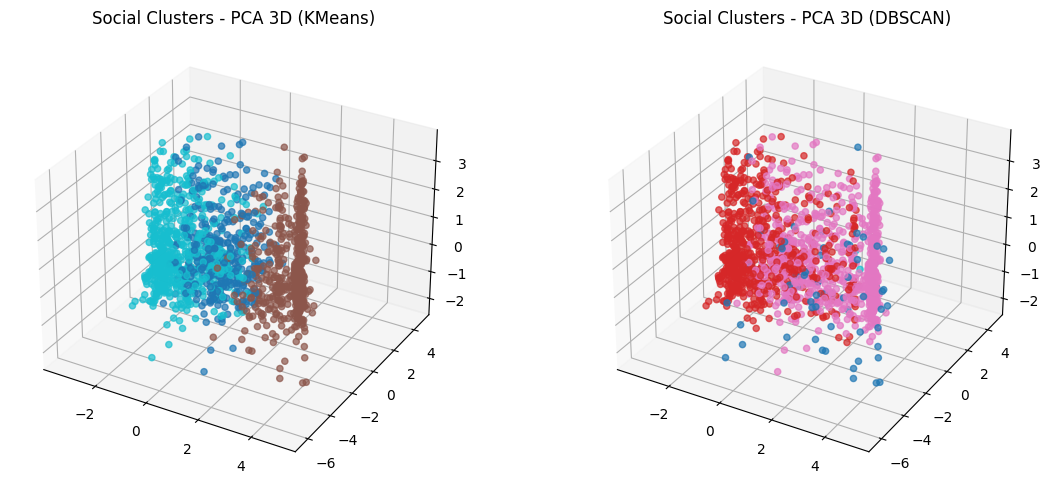

In [20]:
def visualize(df, name="Cluster Visualization"):
    # Lấy các cột số
    numeric_cols = df.select_dtypes(include='number').columns.drop(['kmeans', 'dbscan'], errors='ignore')
    # Chuẩn hóa dữ liệu
    X_scaled = StandardScaler().fit_transform(df[numeric_cols].fillna(0))

    # PCA giảm chiều
    pca2 = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
    pca3 = PCA(n_components=3, random_state=42).fit_transform(X_scaled)

    df2_k = pd.DataFrame(pca2, columns=['PC1', 'PC2'])
    df2_k['Cluster'] = df['kmeans']
    df2_d = pd.DataFrame(pca2, columns=['PC1', 'PC2'])
    df2_d['Cluster'] = df['dbscan']

    df3_k = pd.DataFrame(pca3, columns=['PC1', 'PC2', 'PC3'])
    df3_k['Cluster'] = df['kmeans']
    df3_d = pd.DataFrame(pca3, columns=['PC1', 'PC2', 'PC3'])
    df3_d['Cluster'] = df['dbscan']

    #  Biểu đồ  2D
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.scatterplot(data=df2_k, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.7)
    plt.title(f'{name} - PCA 2D (KMeans)')

    plt.subplot(1, 2, 2)
    sns.scatterplot(data=df2_d, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.7)
    plt.title(f'{name} - PCA 2D (DBSCAN)')

    plt.tight_layout()
    plt.show()

    #  Biểu đồ  3D
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(df3_k['PC1'], df3_k['PC2'], df3_k['PC3'], c=df3_k['Cluster'], cmap='tab10', alpha=0.7)
    ax1.set_title(f'{name} - PCA 3D (KMeans)')

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(df3_d['PC1'], df3_d['PC2'], df3_d['PC3'], c=df3_d['Cluster'], cmap='tab10', alpha=0.7)
    ax2.set_title(f'{name} - PCA 3D (DBSCAN)')

    plt.tight_layout()
    plt.show()

visualize(activity_cluster, name="Activity Clusters")
visualize(social_cluster,  name="Social Clusters")

